In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "16"

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import matplotlib.patheffects as pe
import pickle
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
import statsmodels

import sys
sys.path.append('/Users/idse/repos/signaldecoding/2D_gastruloids_v5')
import fns_plotting_scripts as fns_plot
import fns_NN
import IIF_analysis as IIF

import importlib
importlib.reload(IIF);
importlib.reload(fns_plot);

import warnings
from sklearn.exceptions import InconsistentVersionWarning
import time
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

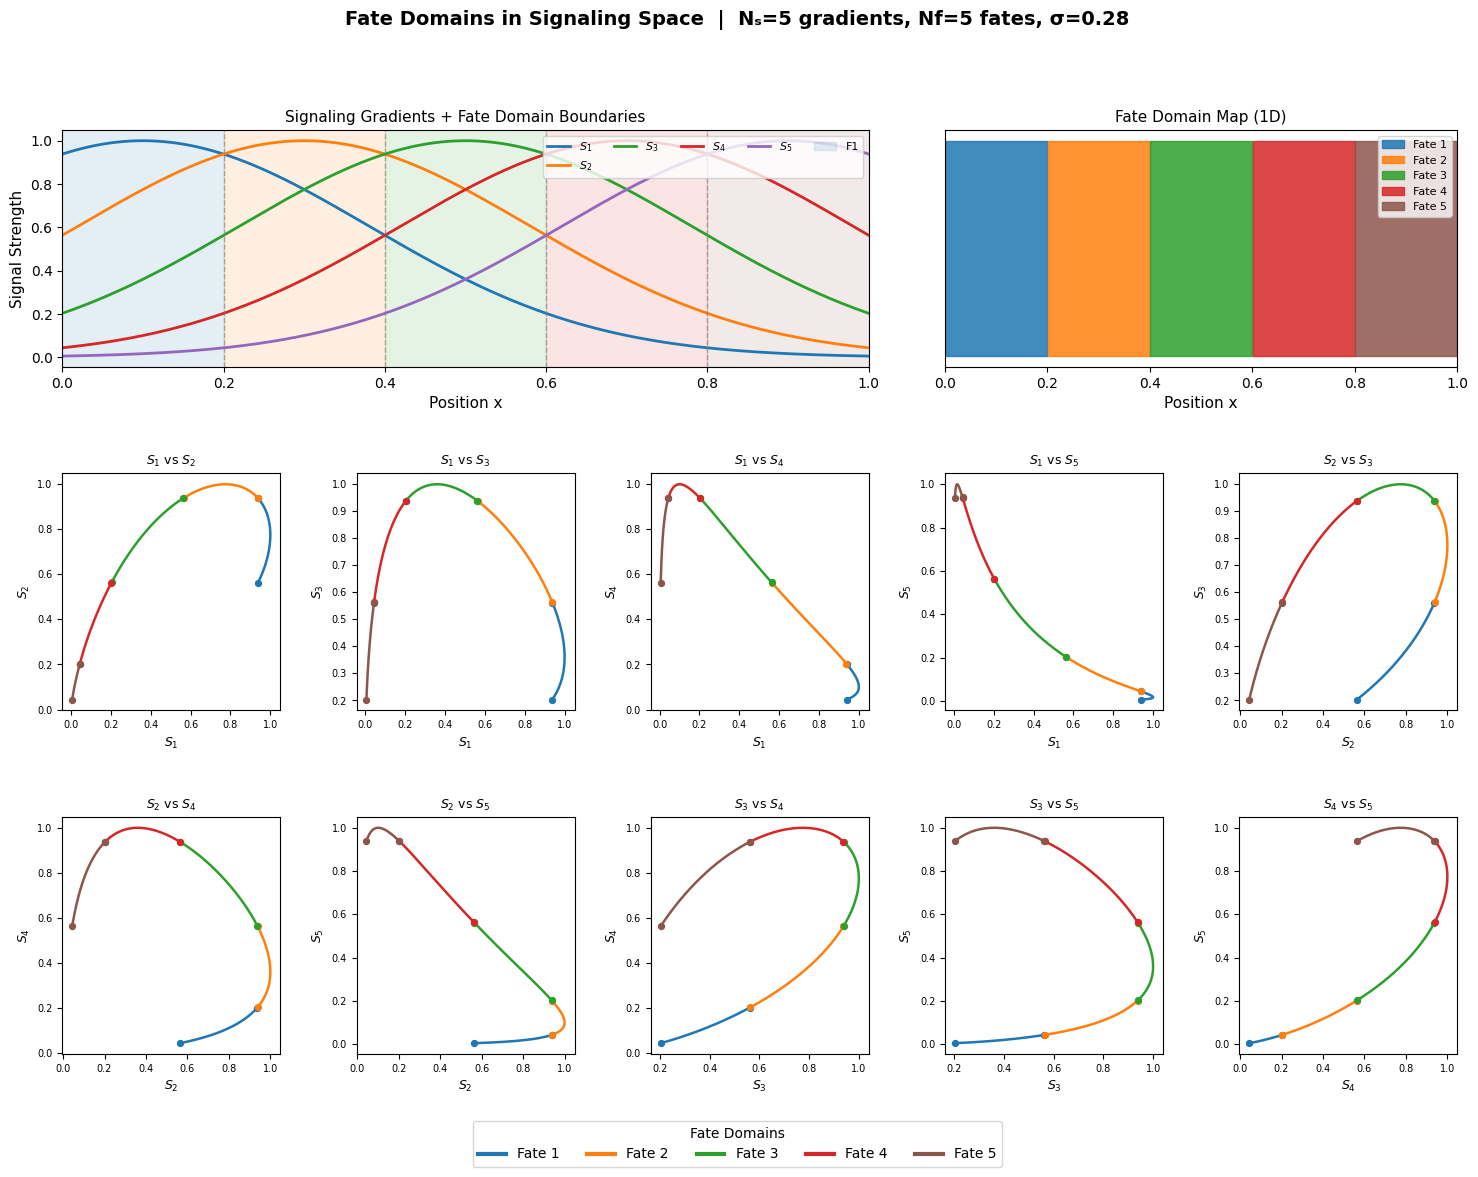

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
R   = 1.0          # Domain length
Ns  = 5            # Number of signaling gradients
Nf  = 5            # Number of fate domains
Nx  = 1000         # Spatial resolution

x   = np.linspace(0, R, Nx)

# Fate domain boundaries and labels
fate_boundaries = np.linspace(0, R, Nf + 1)
fate_labels     = np.array([
    int((xi / R) * Nf) for xi in x
])
fate_labels     = np.clip(fate_labels, 0, Nf - 1)

# Colors for each fate
fate_colors = plt.cm.tab10(np.linspace(0, 0.5, Nf))

# ─────────────────────────────────────────────
# Define Signaling Gradients
# Gaussian peaks with centers spread across [0, R]
# and partial overlap (sigma controls overlap)
# ─────────────────────────────────────────────
def gaussian_gradient(x, center, sigma, amplitude=1.0):
    return amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)

sigma     = 0.28          # controls overlap (larger = more overlap)
centers   = np.linspace(0.1, 0.9, Ns)
amplitudes = np.ones(Ns)  # uniform amplitude; try randomizing!

# Build signal matrix S: shape (Nx, Ns)
S = np.column_stack([
    gaussian_gradient(x, c, sigma, a)
    for c, a in zip(centers, amplitudes)
])

# ─────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f"Fate Domains in Signaling Space  |  "
    f"Nₛ={Ns} gradients, Nf={Nf} fates, σ={sigma}",
    fontsize=14, fontweight='bold'
)

gs = GridSpec(3, 5, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Spatial gradients ───────────────
ax_grad = fig.add_subplot(gs[0, :3])
for i in range(Ns):
    ax_grad.plot(x, S[:, i], lw=2, label=f"$S_{i+1}$")
for k in range(Nf):
    ax_grad.axvspan(
        fate_boundaries[k], fate_boundaries[k+1],
        alpha=0.12, color=fate_colors[k], label=f"F{k+1}" if k == 0 else ""
    )
for b in fate_boundaries[1:-1]:
    ax_grad.axvline(b, color='gray', lw=1, ls='--', alpha=0.6)
ax_grad.set_xlabel("Position x", fontsize=11)
ax_grad.set_ylabel("Signal Strength", fontsize=11)
ax_grad.set_title("Signaling Gradients + Fate Domain Boundaries", fontsize=11)
ax_grad.legend(loc='upper right', ncol=Ns, fontsize=8)
ax_grad.set_xlim(0, R)

# ── Panel 2: Fate domain coloring in 1D ──────
ax_fate = fig.add_subplot(gs[0, 3:])
for k in range(Nf):
    mask = fate_labels == k
    ax_fate.fill_between(
        x[mask], 0, 1,
        color=fate_colors[k], alpha=0.85, label=f"Fate {k+1}"
    )
ax_fate.set_xlabel("Position x", fontsize=11)
ax_fate.set_title("Fate Domain Map (1D)", fontsize=11)
ax_fate.set_yticks([])
ax_fate.legend(loc='upper right', fontsize=8)
ax_fate.set_xlim(0, R)

# ── Panels 3–12: All pairwise 2D projections ─
signal_pairs = list(combinations(range(Ns), 2))   # 10 pairs for Ns=5

for idx, (i, j) in enumerate(signal_pairs):
    row = 1 + idx // 5
    col = idx % 5
    ax  = fig.add_subplot(gs[row, col])

    for k in range(Nf):
        mask = fate_labels == k
        ax.plot(
            S[mask, i], S[mask, j],
            color=fate_colors[k],
            lw=1.8,
            label=f"F{k+1}",
            solid_capstyle='round'
        )
        # Mark start and end of each arc
        ax.scatter(S[mask, i][[0, -1]], S[mask, j][[0, -1]],
                   color=fate_colors[k], s=18, zorder=5)

    ax.set_xlabel(f"$S_{i+1}$", fontsize=9)
    ax.set_ylabel(f"$S_{j+1}$", fontsize=9)
    ax.set_title(f"$S_{i+1}$ vs $S_{j+1}$", fontsize=9)
    ax.tick_params(labelsize=7)

# Shared legend for fates
handles = [
    plt.Line2D([0], [0], color=fate_colors[k], lw=3, label=f"Fate {k+1}")
    for k in range(Nf)
]
fig.legend(handles=handles, loc='lower center', ncol=Nf,
           fontsize=10, title="Fate Domains", title_fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.savefig("fate_signaling_space.png", dpi=150, bbox_inches='tight')
plt.show()

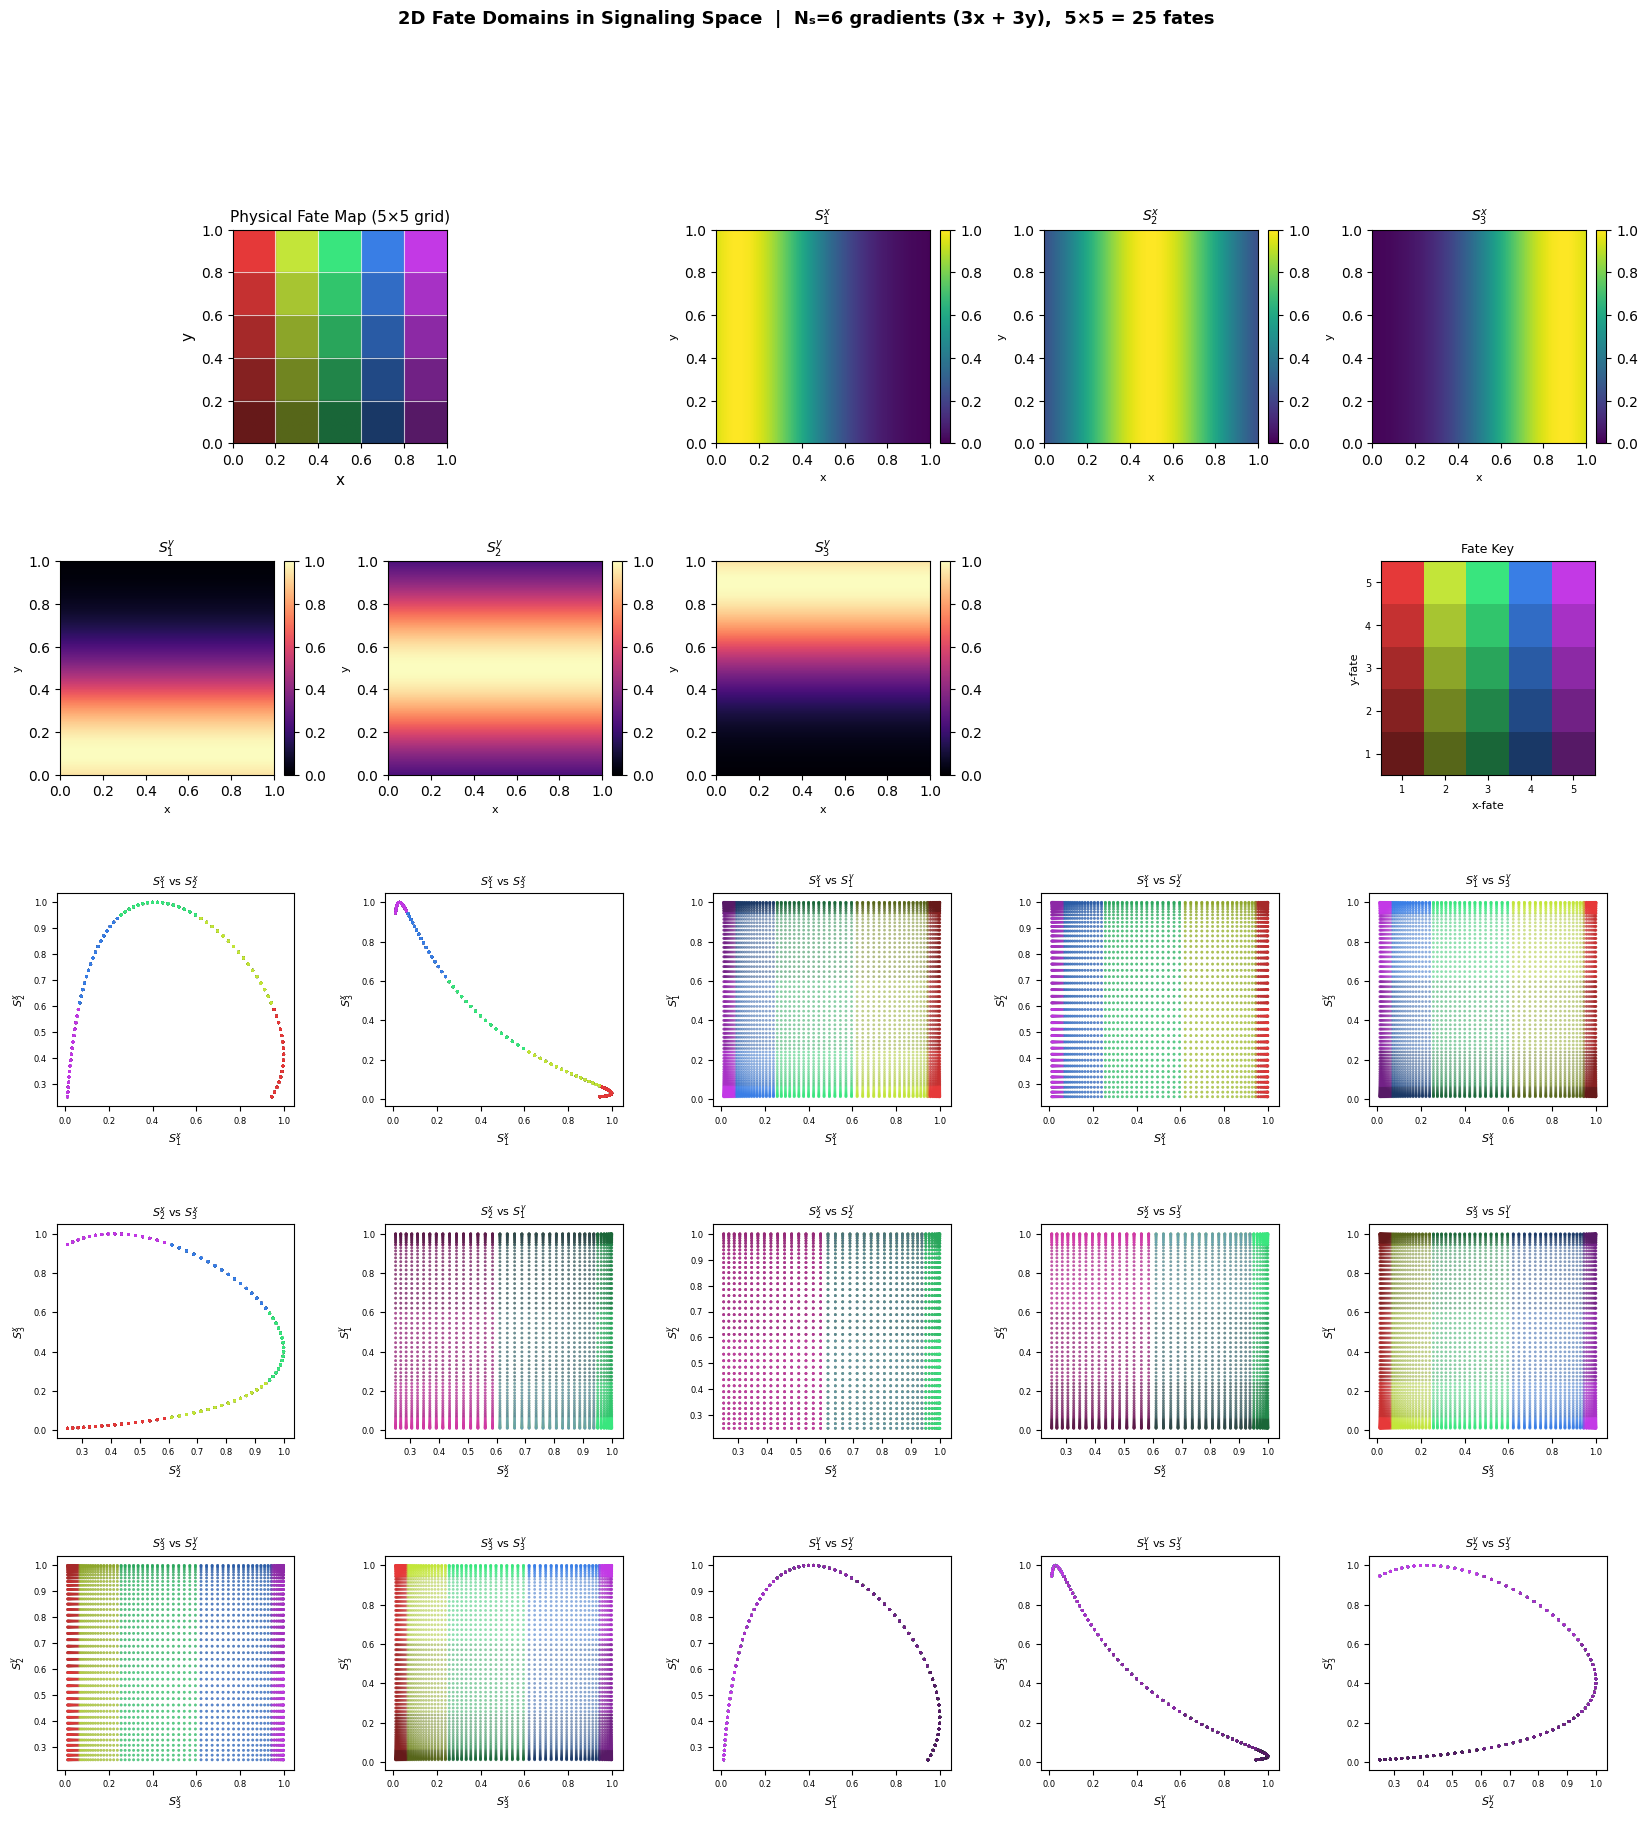

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.gridspec import GridSpec
from matplotlib.colors import hsv_to_rgb

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
R       = 1.0
Ns_x    = 3       # gradients along x-axis
Ns_y    = 3       # gradients along y-axis
Ns      = Ns_x + Ns_y   # total = 6
Nf      = 5       # fate divisions per axis → Nf x Nf grid
Ng      = 80      # grid resolution per axis
NCOLS   = 5       # columns in the projection panel

sigma_x = 0.30
sigma_y = 0.30

# ─────────────────────────────────────────────
# Build spatial grid
# ─────────────────────────────────────────────
xv      = np.linspace(0, R, Ng)
yv      = np.linspace(0, R, Ng)
XX, YY  = np.meshgrid(xv, yv)
x_flat  = XX.ravel()
y_flat  = YY.ravel()

# ─────────────────────────────────────────────
# Define Gradients
# ─────────────────────────────────────────────
def gaussian_1d(coord, center, sigma):
    return np.exp(-0.5 * ((coord - center) / sigma) ** 2)

centers_x = np.linspace(0.1, 0.9, Ns_x)
centers_y = np.linspace(0.1, 0.9, Ns_y)

Sx = np.column_stack([gaussian_1d(x_flat, c, sigma_x) for c in centers_x])
Sy = np.column_stack([gaussian_1d(y_flat, c, sigma_y) for c in centers_y])
S  = np.hstack([Sx, Sy])   # shape (Ng^2, Ns)

signal_names = (
    [f"$S^x_{i+1}$" for i in range(Ns_x)] +
    [f"$S^y_{j+1}$" for j in range(Ns_y)]
)

# ─────────────────────────────────────────────
# Assign Fate Domains
# ─────────────────────────────────────────────
boundaries = np.linspace(0, R, Nf + 1)
fate_x  = np.clip((x_flat / R * Nf).astype(int), 0, Nf - 1)
fate_y  = np.clip((y_flat / R * Nf).astype(int), 0, Nf - 1)
fate_id = fate_y * Nf + fate_x
n_fates = Nf * Nf

def fate_color(fx, fy, nf=Nf):
    h = fx / nf
    s = 0.75
    v = 0.40 + 0.50 * (fy / (nf - 1))
    return hsv_to_rgb([h, s, v])

fate_color_map = {
    fy * Nf + fx: fate_color(fx, fy)
    for fx in range(Nf)
    for fy in range(Nf)
}
point_colors = np.array([fate_color_map[fid] for fid in fate_id])

# ─────────────────────────────────────────────
# Compute layout dimensions dynamically
# ─────────────────────────────────────────────
pairs    = list(combinations(range(Ns), 2))   # 15 pairs for Ns=6
n_pairs  = len(pairs)
n_proj_rows = int(np.ceil(n_pairs / NCOLS))   # 3 rows for 15 pairs

# Total rows:
#   row 0        : fate map + x-gradient panels
#   row 1        : y-gradient panels (overflow)
#   rows 2..2+n  : pairwise projections
n_header_rows = 2
n_total_rows  = n_header_rows + n_proj_rows   # = 5

fig = plt.figure(figsize=(20, 4 * n_total_rows))
fig.suptitle(
    f"2D Fate Domains in Signaling Space  |  "
    f"Nₛ={Ns} gradients ({Ns_x}x + {Ns_y}y),  "
    f"{Nf}×{Nf} = {n_fates} fates",
    fontsize=13, fontweight='bold', y=0.99
)

gs = GridSpec(n_total_rows, NCOLS, figure=fig,
              hspace=0.55, wspace=0.38)

# ─────────────────────────────────────────────
# Row 0: Physical fate map (cols 0-1) + x-gradients (cols 2-4)
# ─────────────────────────────────────────────
ax_fate = fig.add_subplot(gs[0, :2])
fate_grid = (fate_y * Nf + fate_x).reshape(Ng, Ng)
fate_img  = np.array([
    [fate_color_map[fate_grid[iy, ix]] for ix in range(Ng)]
    for iy in range(Ng)
])
ax_fate.imshow(fate_img, origin='lower',
               extent=[0, R, 0, R], aspect='equal')
for b in boundaries[1:-1]:
    ax_fate.axvline(b, color='w', lw=0.8, alpha=0.7)
    ax_fate.axhline(b, color='w', lw=0.8, alpha=0.7)
ax_fate.set_xlabel("x", fontsize=11)
ax_fate.set_ylabel("y", fontsize=11)
ax_fate.set_title(f"Physical Fate Map ({Nf}×{Nf} grid)", fontsize=11)

# X-gradients in row 0, cols 2-4
for i in range(Ns_x):
    ax = fig.add_subplot(gs[0, 2 + i])
    sig_2d = S[:, i].reshape(Ng, Ng)
    im = ax.imshow(sig_2d, origin='lower', extent=[0, R, 0, R],
                   cmap='viridis', aspect='equal', vmin=0, vmax=1)
    ax.set_title(signal_names[i], fontsize=10)
    ax.set_xlabel("x", fontsize=8); ax.set_ylabel("y", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ─────────────────────────────────────────────
# Row 1: Y-gradients (cols 0-2) + fate colorbar key (col 4)
# ─────────────────────────────────────────────
for j in range(Ns_y):
    ax = fig.add_subplot(gs[1, j])
    sig_2d = S[:, Ns_x + j].reshape(Ng, Ng)
    im = ax.imshow(sig_2d, origin='lower', extent=[0, R, 0, R],
                   cmap='magma', aspect='equal', vmin=0, vmax=1)
    ax.set_title(signal_names[Ns_x + j], fontsize=10)
    ax.set_xlabel("x", fontsize=8); ax.set_ylabel("y", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Fate key in row 1, col 4
ax_leg = fig.add_subplot(gs[1, 4])
legend_img = np.array([
    [fate_color(fx, fy) for fx in range(Nf)]
    for fy in range(Nf)
])
ax_leg.imshow(legend_img, origin='lower', aspect='equal')
ax_leg.set_xlabel("x-fate", fontsize=8)
ax_leg.set_ylabel("y-fate", fontsize=8)
ax_leg.set_title("Fate Key", fontsize=9)
ax_leg.set_xticks(range(Nf)); ax_leg.set_xticklabels(range(1, Nf+1), fontsize=7)
ax_leg.set_yticks(range(Nf)); ax_leg.set_yticklabels(range(1, Nf+1), fontsize=7)

# ─────────────────────────────────────────────
# Rows 2+: All pairwise 2D signal projections
# ─────────────────────────────────────────────
for idx, (i, j) in enumerate(pairs):
    row = n_header_rows + idx // NCOLS
    col = idx % NCOLS
    ax  = fig.add_subplot(gs[row, col])

    ax.scatter(
        S[:, i], S[:, j],
        c=point_colors,
        s=4, alpha=0.55,
        linewidths=0
    )
    ax.set_xlabel(signal_names[i], fontsize=8)
    ax.set_ylabel(signal_names[j], fontsize=8)
    ax.set_title(f"{signal_names[i]} vs {signal_names[j]}", fontsize=8)
    ax.tick_params(labelsize=6)

plt.savefig("fate_2d_signaling_space.png", dpi=150, bbox_inches='tight')
plt.show()